## Arquivos

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lightkurve import read
import torch

base_dir = Path('../dados')

#contagem de + e - em cada divisão (train, validation, test)
splits = ['train', 'validation', 'test']
classes = ['positives', 'negatives']
total_geral = 0

for split in splits:
    print(f"\n[{split.upper()}]")
    for cls in classes:
        caminho_pasta = base_dir / split / cls
        
        if caminho_pasta.exists():
            # Conta todos os .fits na pasta
            qtd = len(list(caminho_pasta.glob('*.fits')))
            total_geral += qtd
            print(f" {cls.capitalize()}: {qtd} curvas de luz")
        else:
            print(f" {cls.capitalize()}: PASTA NÃO ENCONTRADA ({caminho_pasta})")

print(f"\nTotal geral de curvas no projeto: {total_geral}\n")


[TRAIN]
 Positives: 840 curvas de luz
 Negatives: 766 curvas de luz

[VALIDATION]
 Positives: 190 curvas de luz
 Negatives: 169 curvas de luz

[TEST]
 Positives: 198 curvas de luz
 Negatives: 155 curvas de luz

Total geral de curvas no projeto: 2318



## NaNs e número de pontos

 Arquivo de exemplo selecionado: ../dados/train/positives/TIC_199376584.fits



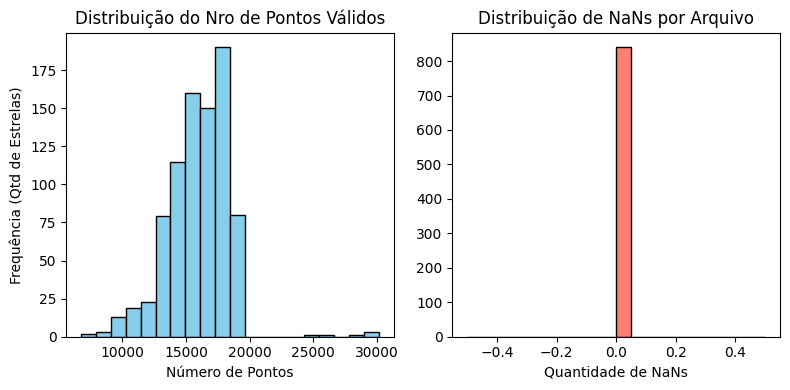

Tamanho Médio (sem NaNs): 16069 pontos
Tamanho Mínimo: 6757 pontos
Tamanho Máximo: 30147 pontos


In [46]:
pasta_alvo = Path('../dados/train/positives')
arquivos = list(pasta_alvo.glob('*.fits'))

if len(arquivos) == 0:
    print(" ERRO:")
else:
    exemplo_path = str(arquivos[0])
    print(f" Arquivo de exemplo selecionado: {exemplo_path}\n")

    tamanhos_brutos = []
    total_nans_lista = []

    # amostra
    amostra = arquivos[:1000] if len(arquivos) > 1000 else arquivos

    for path in amostra:
        lc = read(str(path))
        fluxos = lc.flux.value
        
        # verifica NaNs
        nans = np.isnan(fluxos).sum()
        total_nans_lista.append(nans)
        
        # verifica tamanho real (sem NaNs)
        tamanhos_brutos.append(len(fluxos) - nans)

    plt.figure(figsize=(8, 4))

    # Distribuição dos Tamanhos
    plt.subplot(1, 2, 1)
    plt.hist(tamanhos_brutos, bins=20, color='skyblue', edgecolor='black')
    plt.title('Distribuição do Nro de Pontos Válidos')
    plt.xlabel('Número de Pontos')
    plt.ylabel('Frequência (Qtd de Estrelas)')

    # Quantidade de NaNs
    plt.subplot(1, 2, 2)
    plt.hist(total_nans_lista, bins=20, color='salmon', edgecolor='black')
    plt.title('Distribuição de NaNs por Arquivo')
    plt.xlabel('Quantidade de NaNs')
    plt.tight_layout()
    plt.show()

    print(f"Tamanho Médio (sem NaNs): {np.mean(tamanhos_brutos):.0f} pontos")
    print(f"Tamanho Mínimo: {np.min(tamanhos_brutos)} pontos")
    print(f"Tamanho Máximo: {np.max(tamanhos_brutos)} pontos")

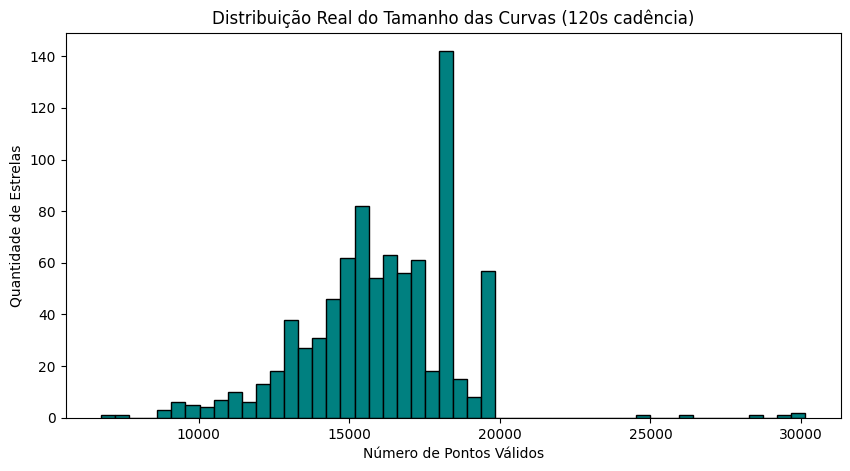

Média de pontos: 16069
Mediana (o valor do meio): 16174
Tamanho Mínimo: 6757
Tamanho Máximo: 30147
Percentil 95: 19610 (95% dos arquivos são menores que isso)


In [47]:
tamanhos_reais = []

for path in arquivos:
    try:
        lc = read(str(path))
        fluxos = lc.flux.value
        
        # Remove NaNs para saber o tamanho real de dados úteis
        valid_mask = ~np.isnan(fluxos) & ~np.isinf(fluxos)
        tamanho_util = np.sum(valid_mask)
        
        tamanhos_reais.append(tamanho_util)
    except Exception as e:
        print(f"Erro ao ler {path.name}: {e}")

tamanhos = np.array(tamanhos_reais)

plt.figure(figsize=(10, 5))
plt.hist(tamanhos, bins=50, color='teal', edgecolor='black')
plt.title('Distribuição Real do Tamanho das Curvas (120s cadência)')
plt.xlabel('Número de Pontos Válidos')
plt.ylabel('Quantidade de Estrelas')
plt.show()

print(f"Média de pontos: {np.mean(tamanhos):.0f}")
print(f"Mediana (o valor do meio): {np.median(tamanhos):.0f}")
print(f"Tamanho Mínimo: {np.min(tamanhos)}")
print(f"Tamanho Máximo: {np.max(tamanhos)}")
print(f"Percentil 95: {np.percentile(tamanhos, 95):.0f} (95% dos arquivos são menores que isso)")

## Especificaçoes dos arquivos

In [48]:
max_size = 0
arquivo_gigante = None
fluxos_gigante = None
lc_gigante = None
amostra = arquivos[:100] if len(arquivos) > 100 else arquivos

for path in amostra:
    lc = read(str(path))
    fluxos = lc.flux.value
    
    # Usando .size em vez de len() para pegar todos os elementos, independente da dimensão
    tamanho_real = fluxos.size 
    
    if tamanho_real > max_size:
        max_size = tamanho_real
        arquivo_gigante = path
        fluxos_gigante = fluxos
        lc_gigante = lc

print(f"arquivo estranho: {arquivo_gigante.name}")
print(f"formato do vetor de fluxo: {fluxos_gigante.shape}")
print(f"total de elementos isolados: {fluxos_gigante.size}")
print(f"Missão / Setor: {lc_gigante.mission} / Setor {getattr(lc_gigante, 'sector', 'Desconhecido')}")
print(f"Colunas do arquivo: {lc_gigante.columns}")

# Verificando se é 1D ou 2D
if len(fluxos_gigante.shape) > 1:
    print("O dado não é uma linha do tempo 1D! Ele tem múltiplas dimensões (provavelmente matrizes de pixels ou múltiplas aberturas).")
else:
    print("É 1D, mas tem dados demais. Pode ser uma curva de luz concatenada de vários anos ou um erro de salvamento.")

import warnings

# Suprime avisos de depreciação para manter o terminal limpo
warnings.filterwarnings('ignore')

BASE_POS = Path('../dados/train/positives')
BASE_NEG = Path('../dados/train/negatives')

def teste_1_flux_origin():
    """Verifica qual coluna de fluxo a biblioteca está usando por padrão."""
    path = list(BASE_POS.glob('*.fits'))[0]
    lc = read(str(path))
    origem = lc.meta.get('FLUX_ORIGIN', 'Desconhecido')
    print("Origem do Fluxo:")
    print(f"O lc.flux está puxando a coluna: {origem} (O ideal é pdcsap_flux)\n")

teste_1_flux_origin()

arquivo estranho: TIC_33595516.fits
formato do vetor de fluxo: (29581,)
total de elementos isolados: 29581
Missão / Setor: TESS / Setor 97
Colunas do arquivo: <TableColumns names=('time','flux','flux_err','cadenceno','quality','centroid_col','centroid_row','mom_centr1','mom_centr2')>
É 1D, mas tem dados demais. Pode ser uma curva de luz concatenada de vários anos ou um erro de salvamento.
Origem do Fluxo:
O lc.flux está puxando a coluna: lightkurve.LightCurve.to_fits() (O ideal é pdcsap_flux)



### Fluxo SAP ou PDCSAP

O teste retornou lightkurve.LightCurve.to_fits(). Isso não significa que os dados estão errados, mas revela um comportamento da biblioteca: quando você usou lc.to_fits() no script de download original, o lightkurve pegou o fluxo PDCSAP (que é o padrão) e o salvou em um arquivo FITS genérico, apagando a "etiqueta" da NASA que dizia que era PDCSAP. Quando usamos author="SPOC", o arquivo .fits baixa ambos. Mas quando chama lc.flux.value, a biblioteca lightkurve usa o PDCSAP por padrão. Não há mistura, você está usando o dado mais limpo possível.

## Pré-processamento feito nos códigos do qusi

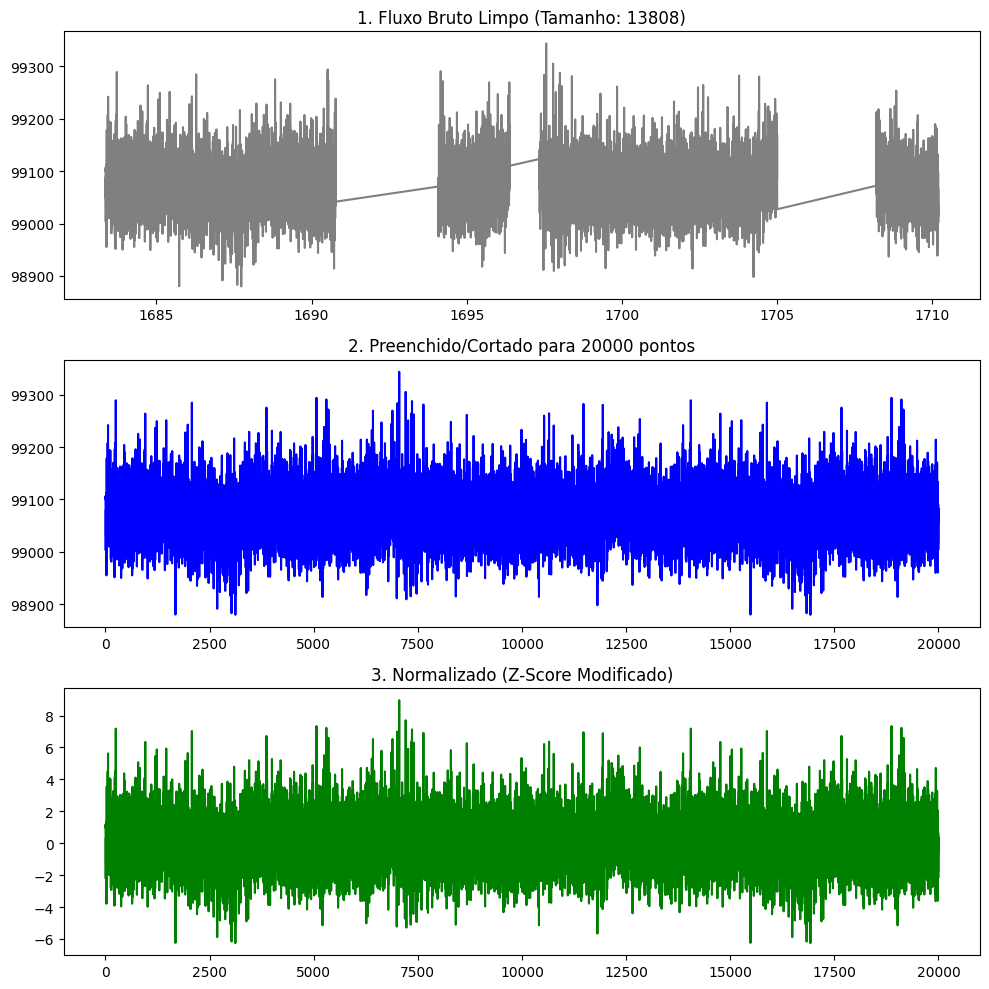

Tipo final: <class 'torch.Tensor'>
Formato (Shape) final que entra na rede neural: torch.Size([20000, 1])


In [49]:
# Lê o arquivo bruto (Objeto Lightkurve)
lc = read(exemplo_path)
tempos_brutos = lc.time.value
fluxos_brutos = lc.flux.value

# Passo 1: Limpa NaNs (Vetor Numpy)
valid_mask = ~np.isnan(fluxos_brutos) & ~np.isinf(fluxos_brutos)
fluxos_limpos = fluxos_brutos[valid_mask]
tempos_limpos = tempos_brutos[valid_mask]

# Passo 2 e 3: Corta/Preenche para 20000 pontos
length = 20000
if len(fluxos_limpos) < length:
    repeats = (length // len(fluxos_limpos)) + 1
    fluxos_pad = np.tile(fluxos_limpos, repeats)[:length]
else:
    fluxos_pad = fluxos_limpos[:length]

# Passo 4: Normalização 
median = np.median(fluxos_pad)
mad = np.median(np.abs(fluxos_pad - median))
if mad == 0: mad = 1e-8
fluxos_norm = (fluxos_pad - median) / mad


fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(tempos_limpos, fluxos_limpos, color='gray')
axes[0].set_title(f"1. Fluxo Bruto Limpo (Tamanho: {len(fluxos_limpos)})")
axes[1].plot(fluxos_pad, color='blue')
axes[1].set_title(f"2. Preenchido/Cortado para {length} pontos")
axes[2].plot(fluxos_norm, color='green')
axes[2].set_title(f"3. Normalizado (Z-Score Modificado)")

plt.tight_layout()
plt.show()

# Passo 5: Converte para Tensor (O que o modelo Hadryss recebe de fato)
tensor_final = torch.tensor(fluxos_norm, dtype=torch.float32).unsqueeze(1)
print(f"Tipo final: {type(tensor_final)}")
print(f"Formato (Shape) final que entra na rede neural: {tensor_final.shape}")

## Plot das curvas de luz baixadas

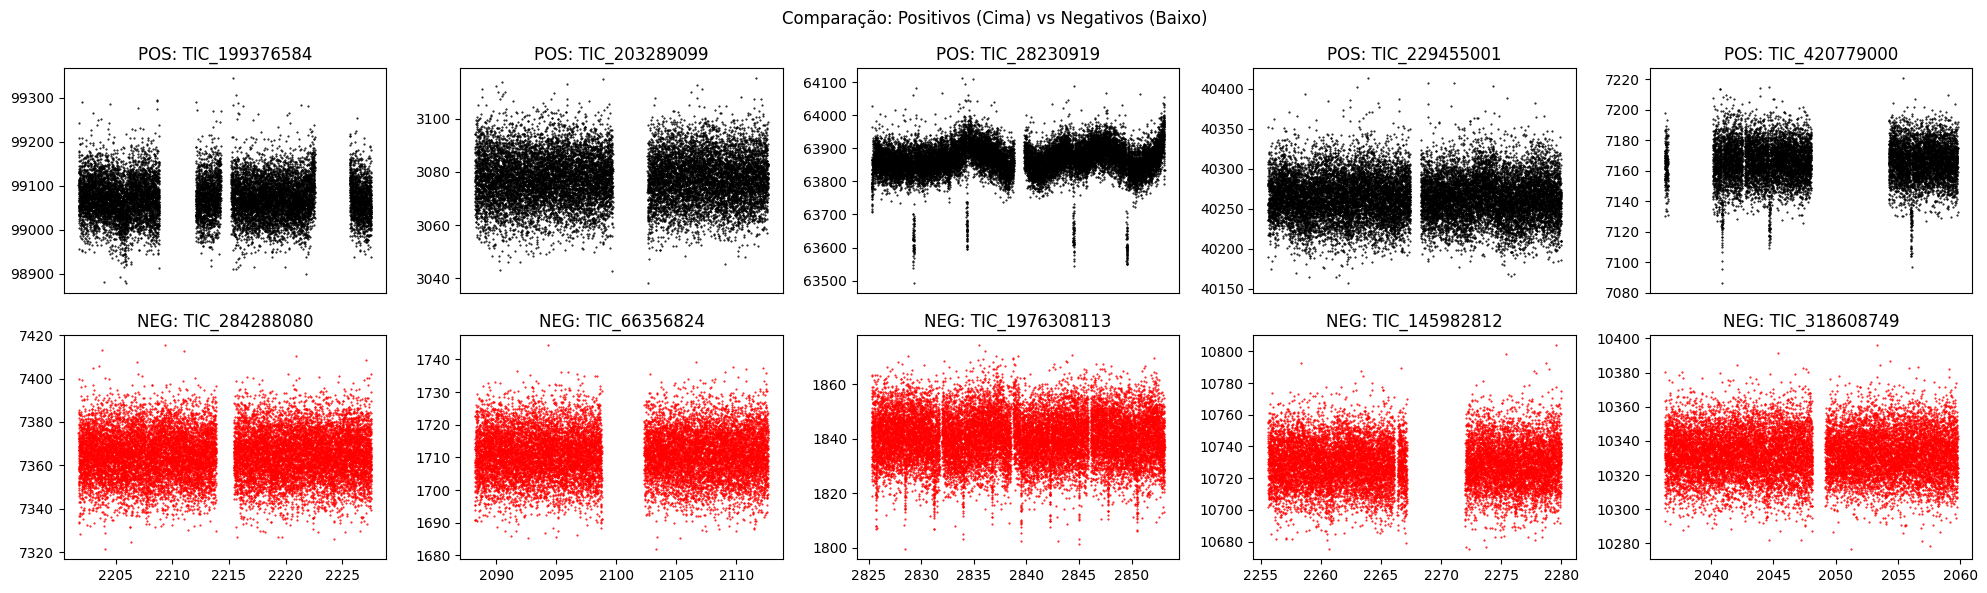

 O trânsito está realmente neste setor? 
Analisando: TIC_199376584.fits
Período mais forte encontrado: 17.70 dias


<Figure size 800x400 with 0 Axes>

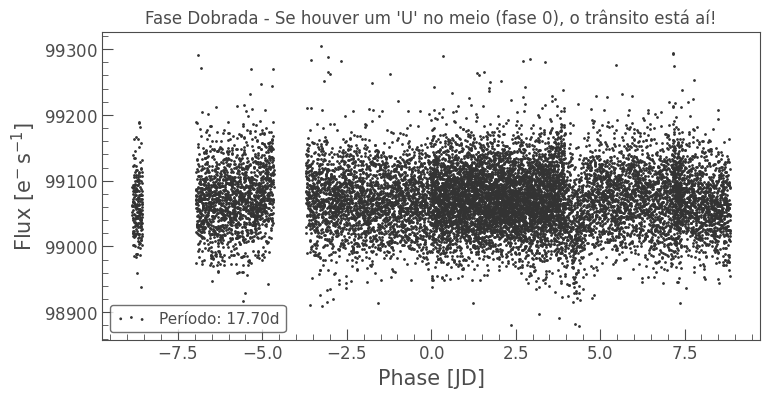

In [50]:
def teste_comparacao_visual_5():
    pos_paths = list(BASE_POS.glob('*.fits'))[:5]
    neg_paths = list(BASE_NEG.glob('*.fits'))[:5]
    fig, axes = plt.subplots(2, 5, figsize=(20, 6))
    fig.suptitle('Comparação: Positivos (Cima) vs Negativos (Baixo)')
    
    for i, path in enumerate(pos_paths):
        lc = read(str(path)).remove_nans()
        # Plota na linha 0 (cima)
        axes[0, i].plot(lc.time.value, lc.flux.value, 'k.', markersize=1)
        axes[0, i].set_title(f"POS: {path.name.replace('.fits','')}")
        axes[0, i].set_xticks([]) # Remove os números do eixo X pra ficar mais limpo
        
    for i, path in enumerate(neg_paths):
        lc = read(str(path)).remove_nans()
        # Plota na linha 1 (baixo)
        axes[1, i].plot(lc.time.value, lc.flux.value, 'r.', markersize=1)
        axes[1, i].set_title(f"NEG: {path.name.replace('.fits','')}")
        
    plt.tight_layout()
    plt.show()

def teste_bls_transit_check():
    #Tentar encontrar o período do planeta na curva.
    print(" O trânsito está realmente neste setor? ")
    path = list(BASE_POS.glob('*.fits'))[0]
    lc = read(str(path)).remove_nans().remove_outliers()
    
    # Roda o Box Least Squares
    periodogram = lc.to_periodogram(method='bls', period=np.arange(0.5, 20, 0.01))
    melhor_periodo = periodogram.period_at_max_power
    
    print(f"Analisando: {path.name}")
    print(f"Período mais forte encontrado: {melhor_periodo.value:.2f} dias")
    
    # Plota a curva dobrada (Phase Folded) no período encontrado
    lc_folded = lc.fold(period=melhor_periodo)
    
    plt.figure(figsize=(8, 4))
    lc_folded.scatter(label=f"Período: {melhor_periodo.value:.2f}d")
    plt.title(f"Fase Dobrada - Se houver um 'U' no meio (fase 0), o trânsito está aí!")
    plt.show()


if __name__ == '__main__':
    teste_comparacao_visual_5()
    teste_bls_transit_check()

Analisando: TIC_199376584.fits
Período mais forte encontrado: 17.70 dias


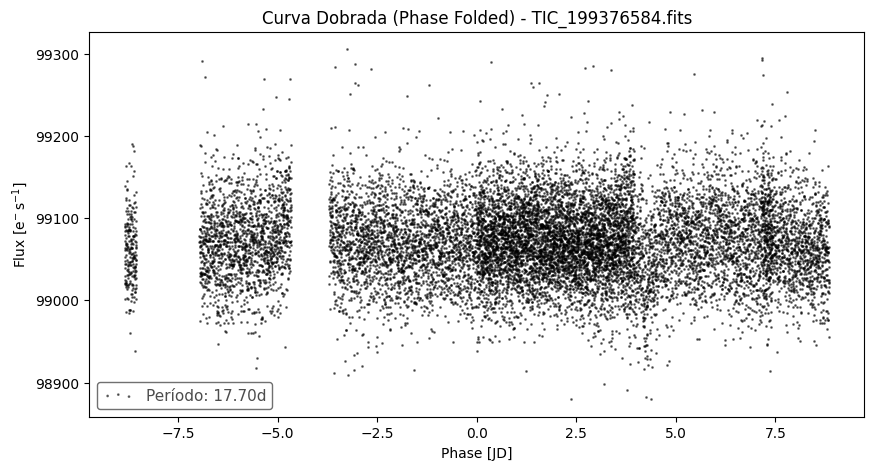

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lightkurve import read

def teste_3_bls_transit_check_corrigido():
    path = list(Path('../dados/train/positives').glob('*.fits'))[0] # Pega o primeiro (TIC 199376584)
    lc = read(str(path)).remove_nans().remove_outliers()
    
    # 1. Roda o Box Least Squares
    periodogram = lc.to_periodogram(method='bls', period=np.arange(0.5, 20, 0.01))
    melhor_periodo = periodogram.period_at_max_power
    
    print(f"Analisando: {path.name}")
    print(f"Período mais forte encontrado: {melhor_periodo.value:.2f} dias")
    
    # 2. Dobra a curva no período encontrado
    lc_folded = lc.fold(period=melhor_periodo)
    
    # 3. Plotagem corrigida (forçando o lightkurve a usar o eixo do matplotlib)
    fig, ax = plt.subplots(figsize=(10, 5))
    lc_folded.scatter(ax=ax, label=f"Período: {melhor_periodo.value:.2f}d", color='black', alpha=0.5)
    ax.set_title(f"Curva Dobrada (Phase Folded) - {path.name}")
    plt.show()

teste_3_bls_transit_check_corrigido()

A. Stitching:
- Alterar o script de download para baixar todos os setores que existem para aquela estrela e costurá-los em uma curva gigante (garantindo que o trânsito estará lá). O problema é que a curva pode ficar com 200.000 pontos.

B. Phase Folding prévio:
- Em vez de dar a curva de tempo inteira para a rede, nós usamos a matemática (o código do teste acima) para "dobrar" todos os dados, transformar em uma única onda, e alimentar a rede neural apenas com a curva já dobrada (onde o trânsito ficará empilhado e gigantesco no meio da tela, mesmo que seja fraco).